In [105]:
# region 1) Packages
import matplotlib.pylab as plt
import seaborn as sns
from scipy import stats

import numpy as np
import pandas as pd
import os 
import warnings
warnings.filterwarnings("ignore")

from itertools import combinations
from functools import partial
from typing import Optional

from sklearn.metrics import r2_score

from mlforecast import MLForecast
from mlforecast.utils import PredictionIntervals

from utilsforecast.plotting import plot_series as plot_series_utils
from utilsforecast.feature_engineering import fourier, pipeline
from utilsforecast.feature_engineering import trend

from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.stats.diagnostic import acorr_ljungbox

from scipy.stats import pearsonr

from fpppy.models import LinearRegression
from fpppy.utils import plot_series

# endregion 
from plotnine import *


# change working directory 
# Check if current directory has any .ipynb files
if any(fname.endswith(".ipynb") for fname in os.listdir()):
    os.chdir("..")

# load local package modules
from gas_pump_prices.preprocess import * 

%load_ext autoreload
%autoreload 2

# region 2) Functions 
def plot_diagnostics(
    forecaster,
    model: Optional[str] = None,
    n_lags: int = None,
    target_col: str = "y",
    id_col: str = "unique_id",
    time_col: str = "ds",
):

    # Plot first model only if no model spec is given
    if model is None:
        model = list(forecaster.models.keys())[0]

    fitted_values = forecaster.forecast_fitted_values()
    insample_forecasts = fitted_values[model]
    residuals = fitted_values[target_col] - insample_forecasts

    fig = plt.figure()

    ax1 = fig.add_subplot(2, 2, (1, 2))
    ax1.plot(fitted_values[time_col], residuals, marker="o")
    ax1.set_title("Residuals")
    ax1.set_ylabel("Residuals")

    ax2 = fig.add_subplot(2, 2, 3)
    plot_acf(residuals.dropna(), ax=ax2, zero=False, lags=n_lags,
             bartlett_confint=False,
             auto_ylims=True)
    ax2.set_xlabel("lag [1Q]")
    ax2.set_ylabel("ACF")

    ax3 = fig.add_subplot(2, 2, 4)
    ax3.hist(residuals, bins=20)
    ax3.set_title("Histogram")
    ax3.set_xlabel("Residuals")
    ax3.set_ylabel("Frequency")

    plt.show()

def print_regression_summary_from_model(model):
    X = model._X.values.astype(float)
    y = model._y
    residuals = model._residuals

    n, p = X.shape
    X_design = np.hstack([np.ones((n, 1)), X])
    df = n - p - 1

    res_summary = np.percentile(residuals, [0, 25, 50, 75, 100])
    print("#> Residuals:")
    print(f"#>     Min      1Q  Median      3Q     Max ")
    print(f"#> {res_summary[0]:7.4f} {res_summary[1]:7.4f} "
          f"{res_summary[2]:7.4f} {res_summary[3]:7.4f} "
          f"{res_summary[4]:7.4f}\n")

    coef = np.insert(model.coef_, 0, model.intercept_)
    rss = np.sum(residuals ** 2)
    mse = rss / df
    var_beta = mse * np.linalg.inv(X_design.T @ X_design).diagonal()
    se_beta = np.sqrt(var_beta)
    t_stats = coef / se_beta
    p_values = 2 * (1 - stats.t.cdf(np.abs(t_stats), df))

    print("#> Coefficients:")
    print(f"#> {'':>13} {'Estimate':>9} {'Std. Error':>11} {'t value':>9} "
          f"{'Pr(>|t|)':>9}")
    names = ['(Intercept)'] + model._var_names
    for name, est, se, t, p in zip(names, coef, se_beta, t_stats, p_values):
        stars = (
            '***' if p < 0.001 else
            '**' if p < 0.01 else
            '*' if p < 0.05 else
            '.' if p < 0.1 else
            ''
        )
        print(f"#> {name:>13} {est:9.4f} {se:11.4f} {t:9.2f} {p:9.3g} "
              f"{stars}")
    print("---")
    print("Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1")

    r_squared = model.score(X, y)
    adj_r_squared = 1 - (1 - r_squared) * (n - 1) / df
    f_stat = (r_squared / p) / ((1 - r_squared) / df)
    f_pval = 1 - stats.f.cdf(f_stat, p, df)

    print(f"\nResidual standard error: {np.sqrt(mse):.3f} "
          f"on {df} degrees of freedom")
    print(f"Multiple R-squared: {r_squared:.3f},   "
          f"Adjusted R-squared: {adj_r_squared:.3f}")
    print(f"F-statistic: {f_stat:.1f} on {p} and {df} DF, "
          f"p-value: {f_pval:.3g}")


def adj_r2_score(y, y_hat, T, k):
    r2 = r2_score(y, y_hat)
    adj_r2 = 1 - (1 - r2) * (T - 1) / (T - k - 1)
    return adj_r2


def aic_score(y, y_hat, T, k):
    sse = np.sum((y - y_hat) ** 2)
    aic = T * np.log(sse / T) + 2 * (k + 2)
    return aic


def aicc_score(y, y_hat, T, k):
    aic = aic_score(y, y_hat, T, k)
    aicc = aic + (2 * (k + 2) * (k + 3)) / (T - k - 3)
    return aicc


def bic_score(y, y_hat, T, k):
    sse = np.sum((y - y_hat) ** 2)
    bic = T * np.log(sse / T) + (k + 2) * np.log(T)
    return bic


def cv_score(mf, df, model, target_col, n_windows, h):
    cv_predictions = mf.cross_validation(
        df, fitted=True, n_windows=n_windows, h=h, static_features=[]
    )
    cv_score = np.mean(
        np.sum((cv_predictions[target_col] - cv_predictions[model]) ** 2)
    )

    return cv_score

# endregion 

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Chapter 7: Time series regression models

Discussion around simple regression is fine for didactic purposes. In practice, we need more advanced models that can account for temporal dynamics (i.e., changes in beta coefficients over time). This will be addressed in later chapters. 

## 7.3. Evaluating the regression model 



Recall assumptions of multiple regression: 

1. Residuals have zero-value mean. Otherwise, forecasts will be biased.  
2. Residuals are not correlated. In other words, errors of similar size cluster together. Otherwise, conventional methods of estimating standard errors will underestimate the true variability, leading to false positives. Note that the regression coefficients are not biased. 
3. Residuals are uncorrelated with predictors. Otherwise, the size of residuals correlate with the value of predictors. In this case, coefficients can be come biased (e.g., errors is larger when predictor value is larger). 

### ACF plot of residuals




The residual plots below show some variability over time. Otherwise, there is nothing much else to report. 

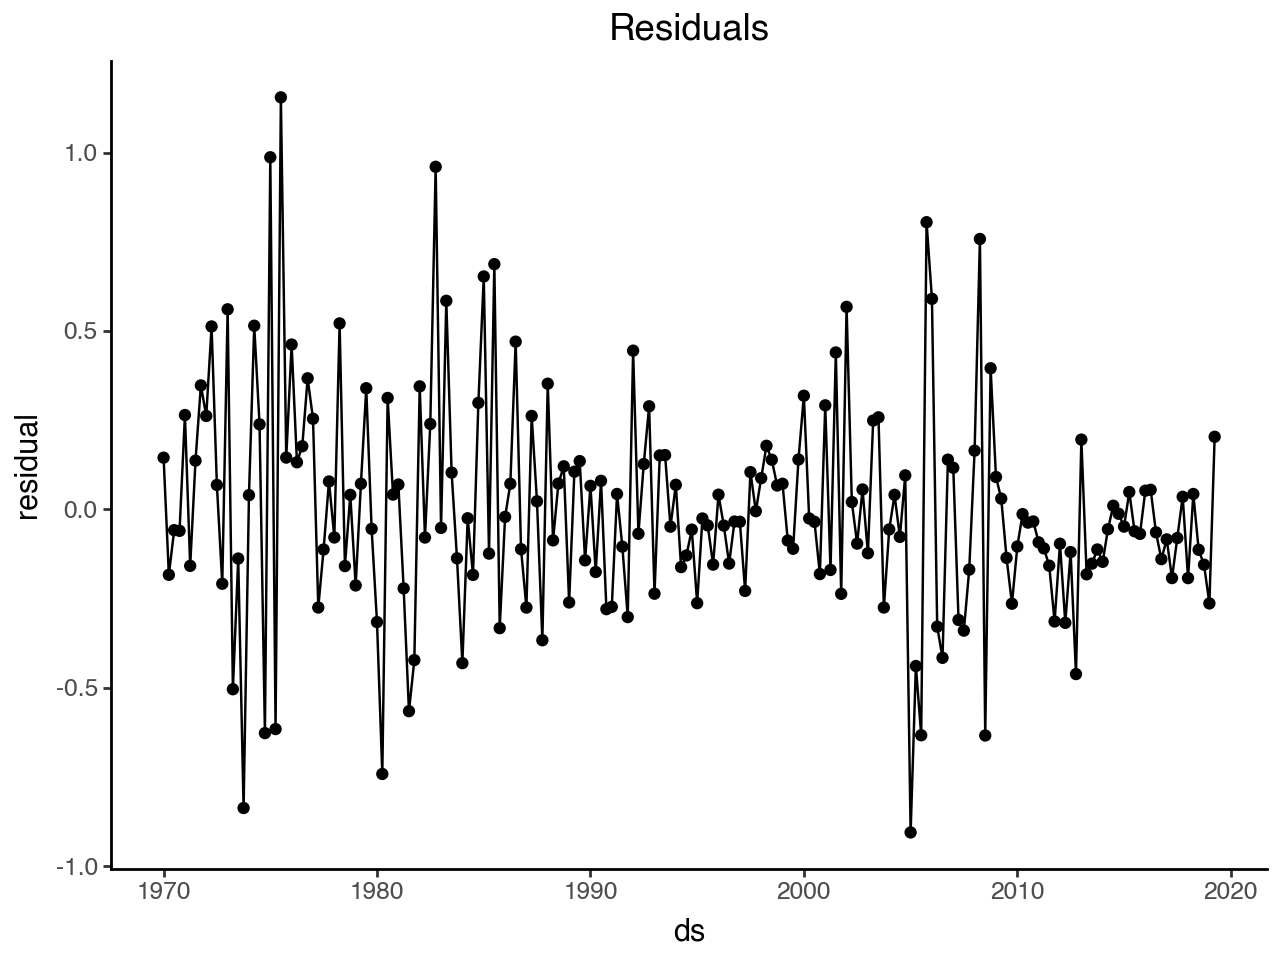

In [72]:
# Example showing evaluation methods for regression time series model on 
# US consumption expenditure data
df_us_con = pd.read_csv('data/raw/US_change.csv', parse_dates=['ds'])

# create linear regression forecasting object
mf = MLForecast(models=LinearRegression(), freq="QS-OCT")

# Fit model
mf.fit(df_us_con, fitted=True, static_features=[])

#print_regression_summary_from_model(mf.models_['LinearRegression'])
df_resid = mf.fcst_fitted_values_
df_resid['residual'] = (df_resid['y'] - df_resid['LinearRegression'])
breaks = pd.date_range(start='1970-01-01', end='2020-01-01', freq='10YS')

# residual plot
(ggplot(data=df_resid, mapping=aes(x='ds', y='residual')) + 
    geom_point() + 
    geom_line() + 
    ggtitle(title="Residuals") + 
    scale_x_date(breaks=breaks, labels=lambda dates: [d.year for d in dates])+
    theme_classic())

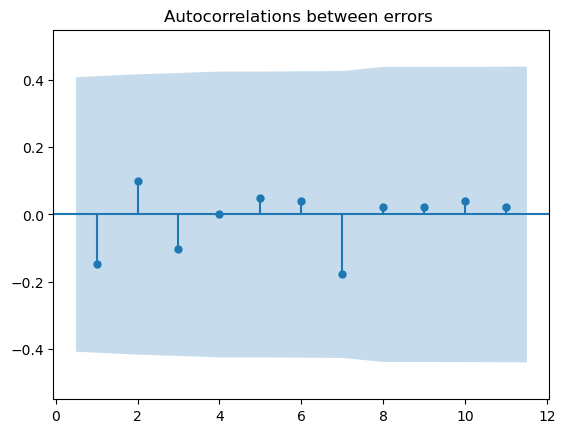

In [62]:
# residual plot
from statsmodels.tsa.stattools import acf

# Compute autocorrelations for lags 1 to 22
resid_acf = acf(df_resid['residual'], nlags=22, fft=False)
plot_acf(x=resid_acf,
         zero=False, bartlett_confint=True, auto_ylims=True, 
         title="Autocorrelations between errors ")

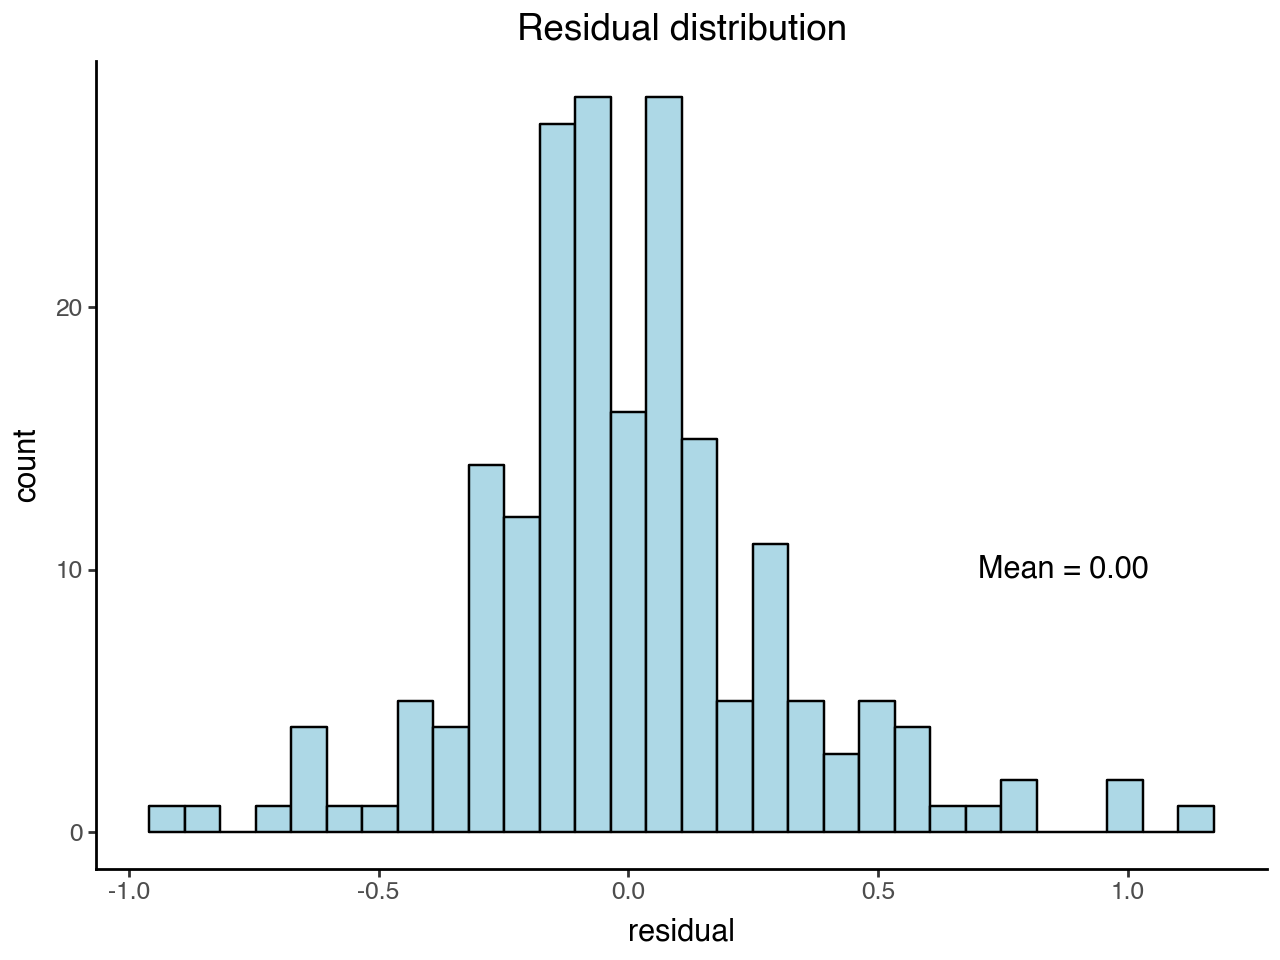

In [68]:
# Distribution of residuals 
 # residual plot
resid_mean = df_resid['residual'].mean()

(ggplot(data=df_resid, mapping=aes(x='residual')) +
    geom_histogram(bins=30, fill="lightblue", color="black") +
    ggtitle("Residual distribution") +
    theme_classic() +
    annotate("text", 
             x=0.7,   # put text near the mean value on x-axis
             y=10,           # adjust depending on histogram height
             label=f"Mean = {resid_mean:.2f}", 
             ha='left', color="black"))

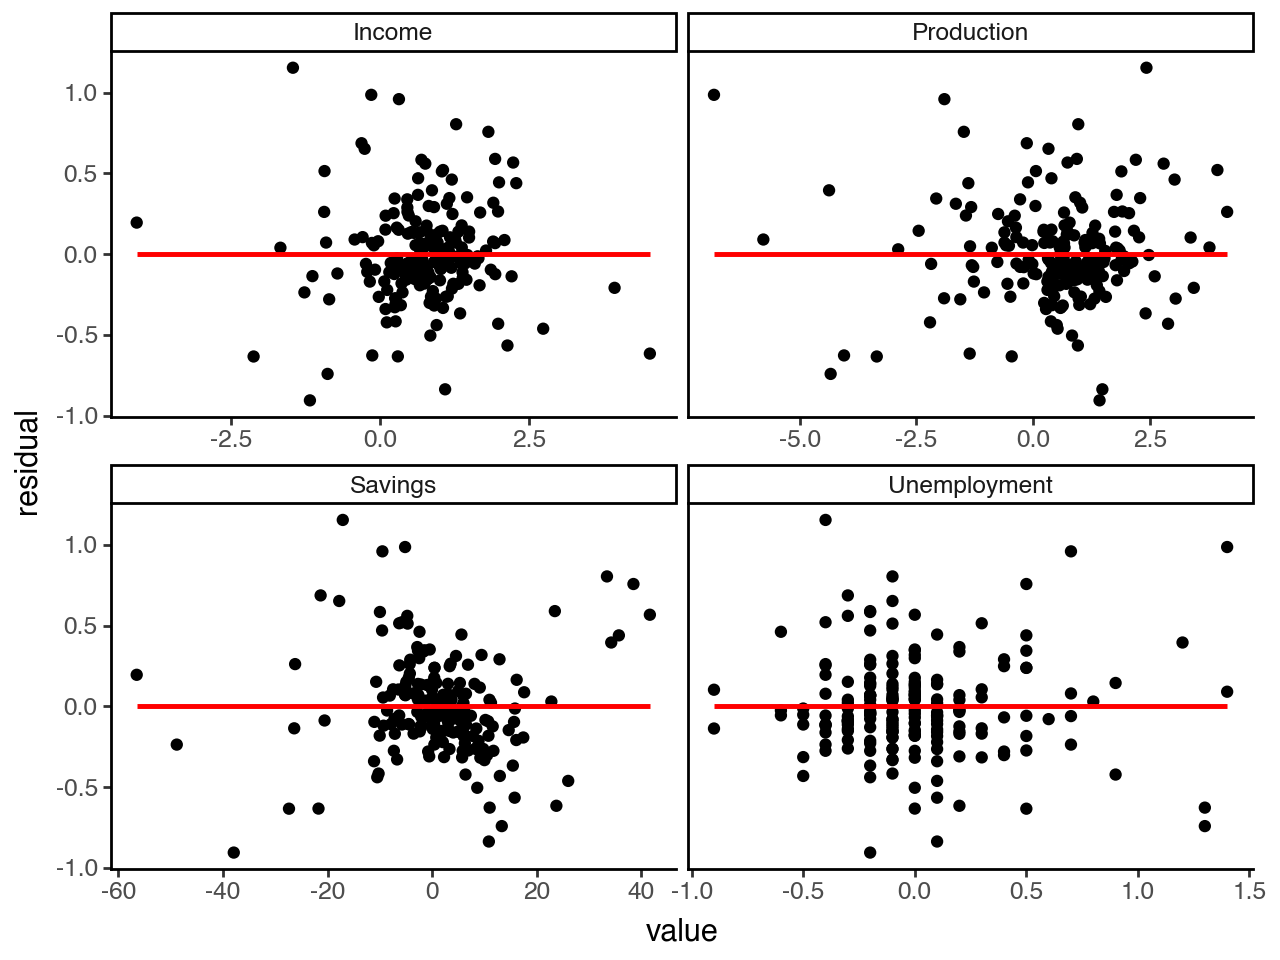

In [ ]:
# Residual plot against predictors
# merge in residuals into original plot 
df_merged = pd.merge(left=df_us_con, right=df_resid[['ds', 'residual']], 
                     on='ds', how='inner')

# convert to long format
pred_vars = ['Income', 'Production', 'Savings', 'Unemployment']
df_long = pd.melt(frame=df_merged, id_vars=['ds', 'residual'], 
                  value_vars=pred_vars)

# plot residuals against predictor values
(ggplot(data=df_long, mapping=aes(x='value', y='residual')) + 
 geom_point() + 
  geom_smooth(method='lm', se=False, color="red") +
 facet_wrap(facets='~variable', scales='free_x') + 
 theme_classic())

### Dummy variables

Binary variables can be inserted to represent special occasions or remove the effect of outliers.  Dummy variables can also be used to model seasonal patterns (e.g., day of week, season of year, etc.). To model seasonal effects, always use n-1 dummy variables. Importantly, when interpreting coefficients on dummy variables, they should be interpreted relative to the effect of the omitted category. 

In the below example, Australian beer production is modelled using a linear trend and quarterly dummy variables. 

$$
y_t = \beta_0  + \beta_1t + \beta_4 d_{2,t} + \beta_3 d_{3,t} + \beta_4 d_{4,t}, 
$$

where $d_{i, t} = 1 if $t$ is in quarter $i$ and 0 otherwise. Note that the first quarter has been omitted so coefficients should be interpreted with respect to this quarter. 

Overall, there is a downward trend in production of .34 megalitres per quarter. The change in beer production is most pronounced in Q2 wen production is 34.7 megaliters lower than Q1, followed by Q3 at 17.8 megaliters. On average, production is strongest in Q4. 

With respect to the residuals, variability is considerably larger in Q4. Looking at the chart, this makes intuitive sense because spikes always occur in Q4, but the magnitude of these spikes shows considerable variability 

Note that `trend()` is needed to model the overall trend (i.e., upward/downward direction of change) at any given time point. Otherwise, the model could only capture seasonal variation but not any long-term change. 


/opt/anaconda3/lib/python3.12/site-packages/fpppy/utils.py:40: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


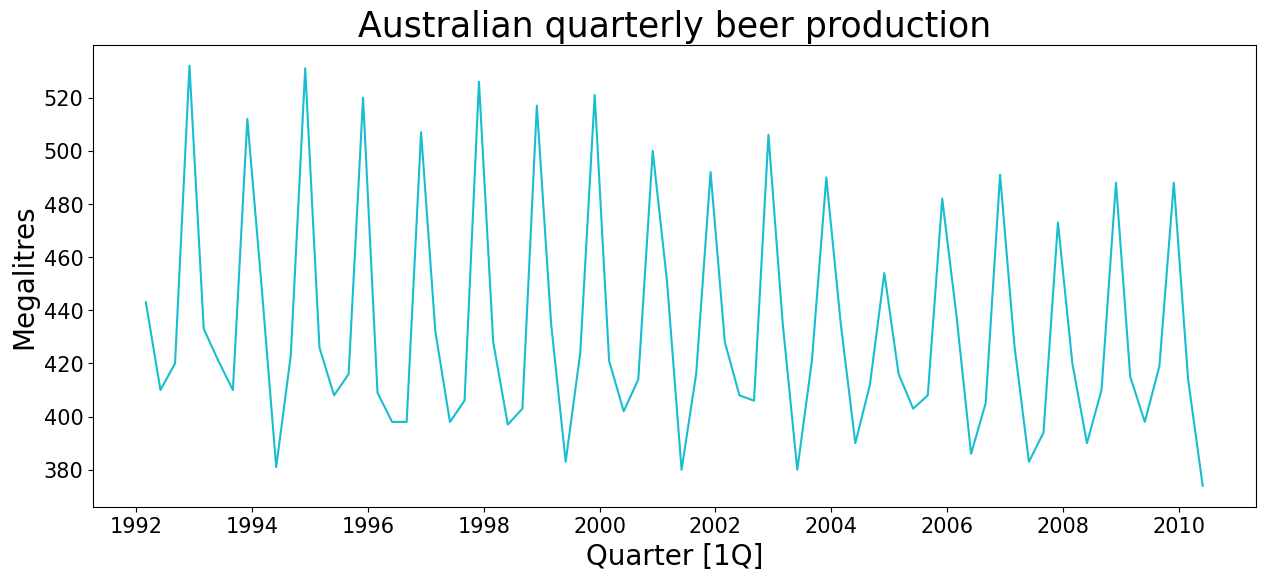

In [89]:
# Australian quarterly beer production 
df_aus_beer = pd.read_csv("data/raw/aus_production_formatted.csv",parse_dates=[1])

df_recent = df_aus_beer.query("unique_id == 'Beer' and ds >= '1992-01-01'").reset_index(drop=True)

plot_series(df_recent,
            xlabel="Quarter [1Q]",
            ylabel="Megalitres",
            title="Australian quarterly beer production")


In [ ]:
fit_beer = df_recent.copy()

# Add trend
fit_beer, _ = trend(fit_beer, freq="QS-DEC")
fit_beer

# Add quarterly indicators
quarter = pd.get_dummies(fit_beer.ds.dt.quarter, prefix="Quarter",
                         drop_first=True)
fit_beer = fit_beer.join(quarter)

# create regression object 
mf = MLForecast(models=LinearRegression(),freq="QS-DEC")
mf.fit(fit_beer, fitted=True, static_features=[])

# extracted predicted/fitte values and residuals 
insample_forecasts = mf.forecast_fitted_values()["LinearRegression"]
residuals = mf.models_["LinearRegression"]._residuals

# print model output 
print_regression_summary_from_model(mf.models_['LinearRegression'])

#> Residuals:
#>     Min      1Q  Median      3Q     Max 
#> -42.9030 -7.5995 -0.4594  7.9908 21.7895

#> Coefficients:
#>                Estimate  Std. Error   t value  Pr(>|t|)
#>   (Intercept)  441.8002      3.7335    118.33         0 ***
#>         trend   -0.3403      0.0666     -5.11  2.73e-06 ***
#>     Quarter_2  -34.6598      3.9683     -8.73   9.1e-13 ***
#>     Quarter_3  -17.8216      4.0225     -4.43  3.45e-05 ***
#>     Quarter_4   72.7964      4.0230     18.09         0 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 12.229 on 69 degrees of freedom
Multiple R-squared: 0.924,   Adjusted R-squared: 0.920
F-statistic: inf on 0.0 and 69 DF, p-value: nan


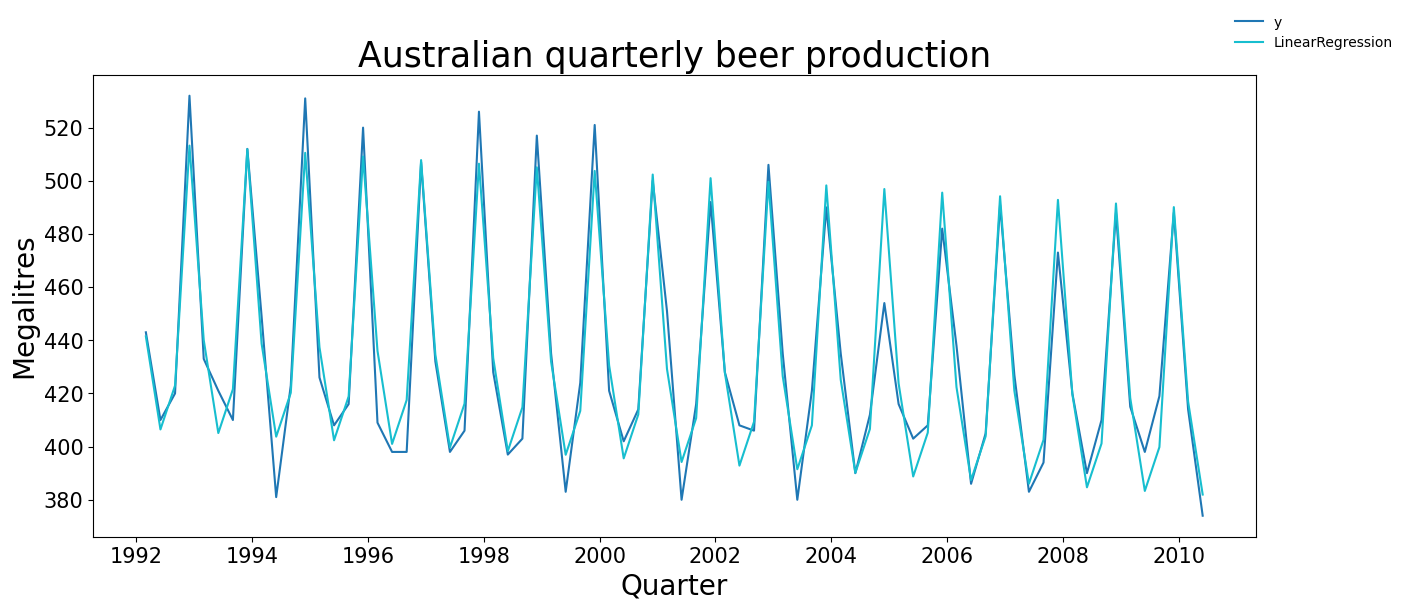

In [103]:
plot_series(df = fit_beer,
  forecasts_df = mf.forecast_fitted_values().drop(columns="y"),
  xlabel = "Quarter",
  ylabel = "Megalitres",
  title = "Australian quarterly beer production",
  rm_legend = False)

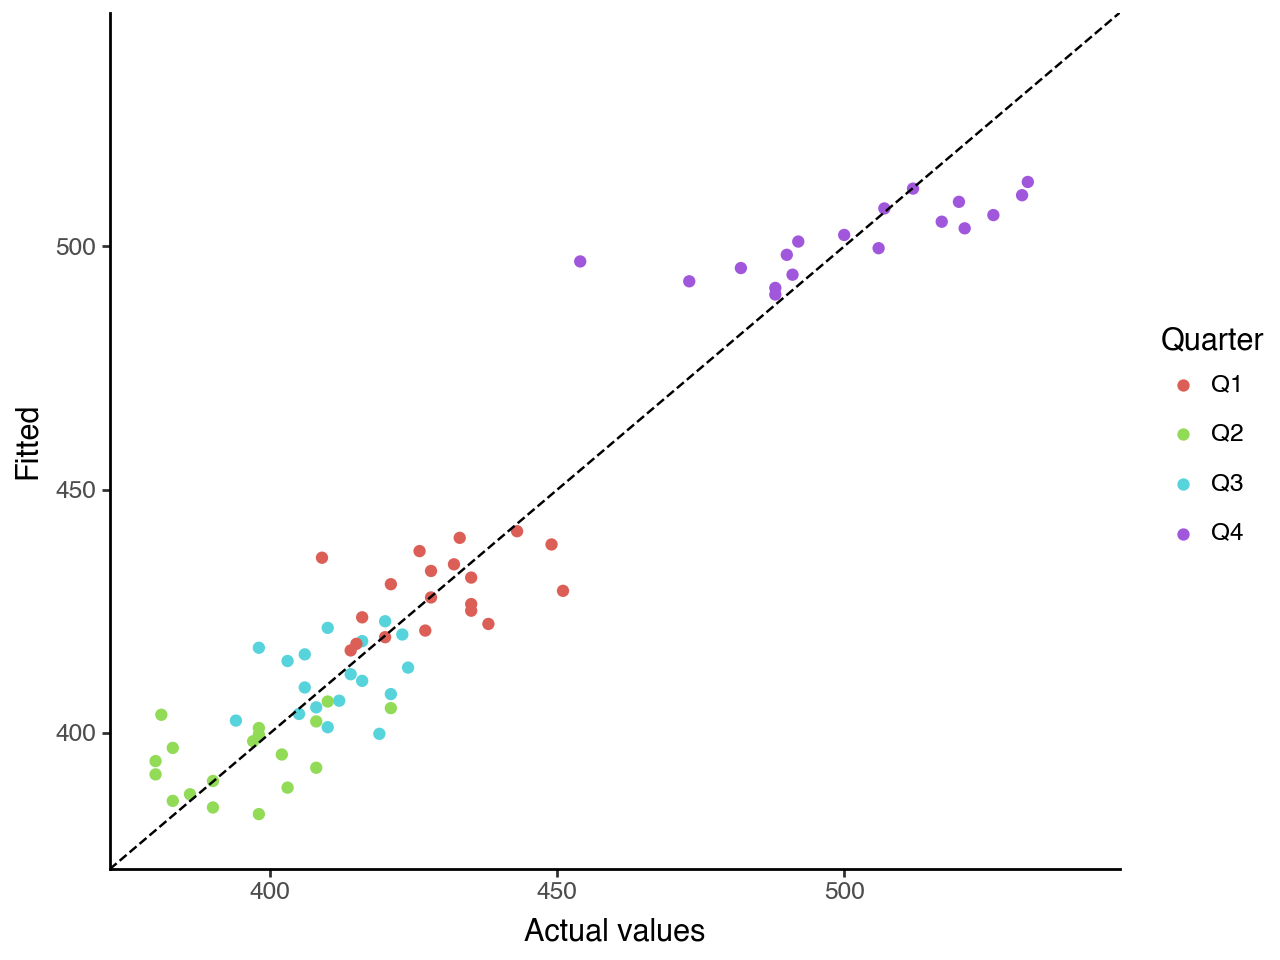

In [111]:
# Examine plot of residuals as function of quarter and actual value 
df_pred = mf.forecast_fitted_values()
df_pred['residual'] = df_pred['y'] - df_pred['LinearRegression']

# add quarter data
df_pred["Quarter"] = "Q" + df_pred["ds"].dt.quarter.astype(str)

(ggplot(data=df_pred, mapping=aes(x='y', y='LinearRegression', 
                                  group='Quarter', color='Quarter')) + 
    geom_point() + 
    geom_abline(slope=1, intercept=0, linetype="dashed", color="black") +
    labs(x='Actual values', y='Fitted') + 
    lims(x=(380, 540), y=(380, 540)) +
    theme_classic())


### Intervention variables 

Interventions oftentimes affect the forecast variable. For example, competitor activity can affect advertising expenditure. 

1. To model interventions that only have an effect for one period, create a dummy variable whose value is 1 only during this period. 
2. If intervention causes permanenet level change, create a dummy variable whose value is 1 after this period. 
3. If intervention causes change in slope, this can be handled using piecewise linear model. 

### Trading days

The number of trading days over a period of time can he handled by either a) creating a predictor that records the number of trading days or b) modelling effects of different days of the week by creating 7 predictors that record the number of each day of the week. 

### Distributed lags 

Consider a situation where monthly sales are being modelled and the effect of advertising expenditure is under consideration. One common method is to model expenditure each month up to a certain lag (e.g., up until 6 months) and assume the effect is strongest initially and then declines over time. 

### Easter 

Easter differs from most holidays because it's date of occurrence changes each year. To account for hthis, use a dummy variable. 

### Fourier series

Beyond the scope of this book, but they are powerful because they can model undulating patterns commonly observed in time series data and use fewer predictors. 

## 7.5. Selecting predictors


Some incorrect approaches: 

1. Plot variables against each other and omit variables if there is no apparent relation. This is invalid because it doesn't account for masking that could occur due to multicollinearity. 
2. Discarding variables that do not have significant relation in multiple regression. 

### Adjusted $R^2$

Adjusted $R^2$, $\bar{R}^2$, improves on $R^2$ because it doesn't simply increase when any predictor is added. Note that maximizing $\bar{R}^2 is identical to minimizing the standard error $\hat{\sigma}_e$. 

$$
\bar{R}^2 = 1 - (1 - R^2) \frac{T-1}{T-k-0},
$$

where T is the number of observations and $k$ is the number of predictors. 

### Cross-validation 

Apparently, normal cross-validation can be used to validate regression models. That is, the assumption that future data cannot be used to predict the past. See paper titled "A Note on the Validity of Cross-Validation for Evaluating Autoregressive Time Series Prediction.". Below is an overview of the procedure: 

1. Remove $t$ observation from data set. Fit model on remaining data and compute residual on $t$ observation. 
2. Repeat for all $t$. 
3. Compute mean squared error on all hold-out residuals. 

### Which measure should we use? 

1. $\bar{R}^2$ tends to select too many predictors. 
2. BIC works in principle in that it will select a true model if it has been created. That being said, BIC is data hungry. 
3. Autors facor using AICc, AIC, or CV approach. 

### Stepwise regression 

Backwards stepwise regression is often effecive. Simply fit a model with all the predictors and the remove one predictor at a time. Iterate until there is no improvement. 

If number of potential predictors is to large, use forward stepwise regression instead. 

For further discussion on stepwise regression, see Introduction to Statistical Learning (Hastie 2014)

## 7.6. Forecasting with regression 


**Ex-ante forecasts** make forecasts using available information. That is, only past information is used to make forecasts. This can involve making forecasts about the predictors using simple methods or more advanced ones. 

**Ex-post forecasts** are made using later information about the predictors. These are not genuine forecasts and generally only useful for studying the behaviour of forecasting methods. Importantly, ex-post forecasting methods should not assume knowledge of the outcome variable to be forecasted. 

Comparing outputs of both models helps determine whether poor performance is due to not knowing the value of predictors or simply having a poor model. 

### Scenario-based forecasting 

In scenario-based forecasting, worst- and best-case scenarios can be simulated by modifying values of important predictors. In the example with US consumption expenditure, we assume constant growth and decline in income and savings of .5% and 1% for each of the four quarters following the end of the sample. 

In [ ]:
df_us_con = pd.read_csv('data/raw/US_change.csv', parse_dates=['ds'])

cols = ["ds", "unique_id", "y", "Income", "Savings", "Unemployment"]
df_scenario = df_us_con[cols].copy()

# Fit model
mf = MLForecast(
    models=LinearRegression(),
    freq="QS-OCT",)

mf.fit(df_scenario,
    static_features=[])

# Generate future data
df_future = mf.make_future_dataframe(h=4)


# Scenario 1 - Increase
df_future["Income"] = 1
df_future["Savings"] = 0.5
df_future["Unemployment"] = 0

# Create forecasts
df_sc1 = mf.predict(h=4, X_df=df_future)
df_sc1 = mf.models_["LinearRegression"].add_prediction_intervals(df_sc1, df_future)
df_sc1.columns = df_sc1.columns.str.replace("LinearRegression", "increase")

# Scenario 2 - Decrease
df_future["Income"] = -1
df_future["Savings"] = -0.5
df_future["Unemployment"] = 0

# Create forecasts
df_sc2 = mf.predict(h=4, X_df=df_future)
df_sc2 = mf.models_["LinearRegression"].add_prediction_intervals(df_sc2, df_future)
df_sc2.columns = df_sc2.columns.str.replace("LinearRegression", "decrease")

df_scenario_merged = pd.merge(left=df_sc1, right=df_sc2, 
                              on=['ds', 'unique_id'])

df_long = df_scenario_merged.melt(id_vars=['unique_id', 'ds'])

(ggplot(data=df_us_con, mapping=aes(x='ds', y='y')) + 
    geom_line() + 
    geom_line(inherit_aes=False, data=df_long, 
              mapping=aes(x='ds', y='value', group='')))

,ds,unique_id,y,Income,Savings,Unemployment
0,1970-01-01,US_change,0.618566,1.044801,5.299014,0.9
1,1970-04-01,US_change,0.451984,1.225647,7.789894,0.5
2,1970-07-01,US_change,0.872872,1.585154,7.403984,0.5
3,1970-10-01,US_change,-0.271848,-0.239545,1.169898,0.7
4,1971-01-01,US_change,1.901345,1.975925,3.535667,-0.1
...,...,...,...,...,...,...
193,2018-04-01,US_change,0.983112,0.661825,-2.723974,0.0
194,2018-07-01,US_change,0.853181,0.806271,-0.085686,-0.3
195,2018-10-01,US_change,0.356512,0.695142,5.031337,0.2
196,2019-01-01,US_change,0.282885,1.100753,9.760287,-0.1


### Building a predictive regression model

Because regression models require future values of predictors to make forecasts, this can introduce an obstacle. One potential solution is to simply model lagged effects for predictors. 

## 7.7. Nonlinear regression


1. Collinearity only causes an issue for scenario-based forecasting, as it becomes difficult to disentangle effects of predictors. 
2. Multicollinearity is only a problem that affects forecasts when there perfect correlations exist. Otherwise, it only causes problems for interpreting regression coefficients.  


## Exercises



### 7.1. Electricity demand in Victoria, Australia

There is an inverted-U relation between daily total demand and mean temperature  such that demand increases exponentially once temperature rises above 30C and increases linearly once temperature drops below 20C. If a quadratic model is fit (using $temperature^2$ as the quadratic predictor), residual properties improve and predictions for temperatures of 15 nad 35 lie close to what you would expect. Looking at the relation between total demand and average temperature at the daily level, the relation is clearly curvilinear. 

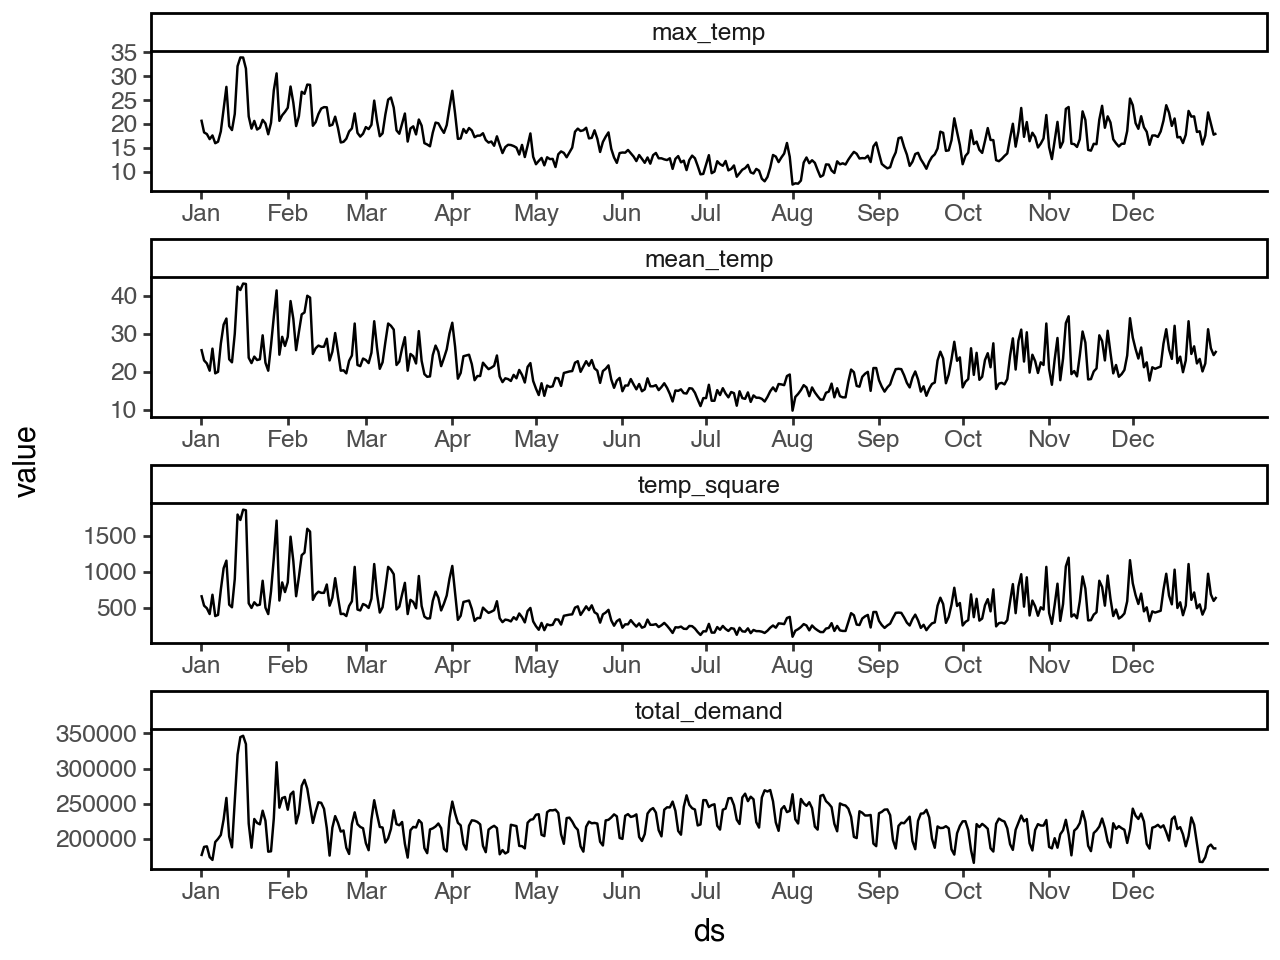

In [ ]:
## Exercises
""" 7.1. Evaluate that residuals hav zero-value mean, are not autocorrelated, are unrelated to any predictor variables, have 
normal distibution, and constant variance"""

df_elec = pd.read_csv('data/raw/vic_elec.csv', parse_dates=['ds'])

df_2014 = df_elec.loc[df_elec['ds'].ge('2014') & df_elec['ds'].lt('2015')]
df_wide = df_2014.pivot(index=['ds'], columns=['unique_id'], values='y').reset_index()

# compute daily aggregates 
df_daily = (df_wide.resample('D', on='ds').agg({'Demand': 'sum',       
       'Temperature': 'mean', 
       "Temperature": ["max", 'mean']}))

df_daily.columns = ['total_demand', 'mean_temp', 'max_temp']
df_daily = df_daily.reset_index()

# add temperature^2
df_daily['temp_square'] = df_daily['mean_temp']**2
df_long = df_daily.melt(id_vars=['ds'])

# patterns over time
breaks = pd.date_range(start=df_long['ds'].min(), 
                       end=df_long['ds'].max(), 
                       freq='MS')  # Month Start

(ggplot(data=df_long, mapping=aes(x='ds', y='value')) + 
    geom_line() + 
    scale_x_date(breaks=breaks, labels=lambda dates: [d.strftime("%b") for d in dates]) +
    facet_wrap(facets='~variable', ncol=1, scales='free') + 
    theme_classic())

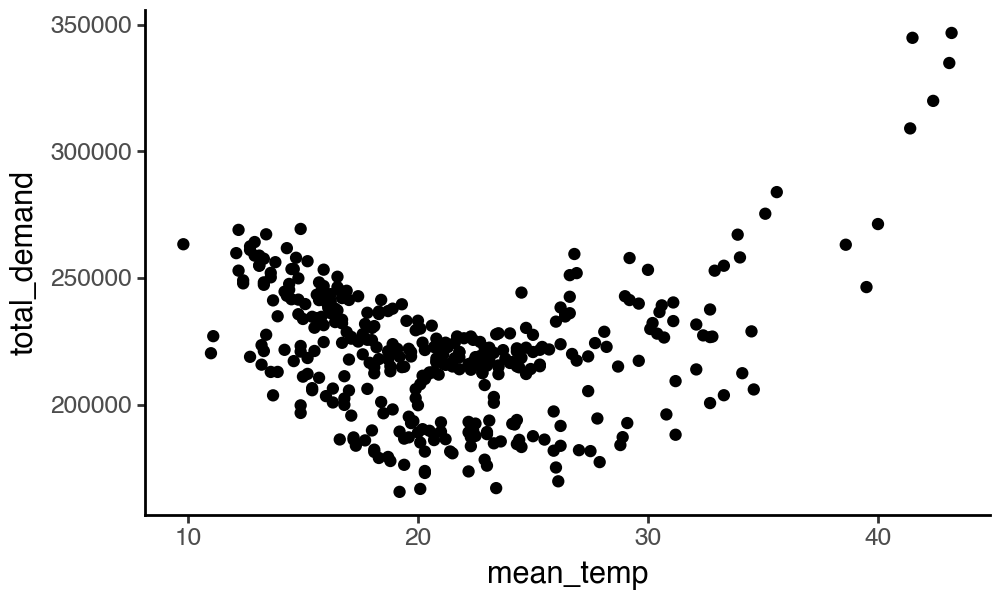

In [215]:
# scatter plot
(ggplot(data=df_daily, mapping=aes(x='mean_temp', y='total_demand')) + 
 geom_point() + 
 theme_classic() + 
 theme(figure_size=(5, 3)))

In [272]:
df_daily['unique_id'] = 'elec_demand'
df_daily.drop('temp_square', axis=1)

# Create lienar model where total demand is rgressed onto mean temperature
mf_model = MLForecast(models=LinearRegression(), freq='D')
mf_model.fit(df=df_daily.drop('max_temp', axis=1), target_col='total_demand', fitted=True, static_features=[])

# create result dataframe
df_result = mf_model.fcst_fitted_values_
df_result['residual'] = df_result['total_demand'] - df_result['LinearRegression']

print(print_regression_summary_from_model(mf_model.models_['LinearRegression']))

#> Residuals:
#>     Min      1Q  Median      3Q     Max 
#> -47999.5917 -17858.1194 6015.5940 14391.7579 48883.0497

#> Coefficients:
#>                Estimate  Std. Error   t value  Pr(>|t|)
#>   (Intercept) 387529.8279  10737.6443     36.09         0 ***
#>     mean_temp -15269.6751    918.2580    -16.63         0 ***
#>   temp_square  323.3933     18.6172     17.37         0 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 19628.090 on 362 degrees of freedom
Multiple R-squared: 0.460,   Adjusted R-squared: 0.457
F-statistic: inf on 0.0 and 362 DF, p-value: nan
None


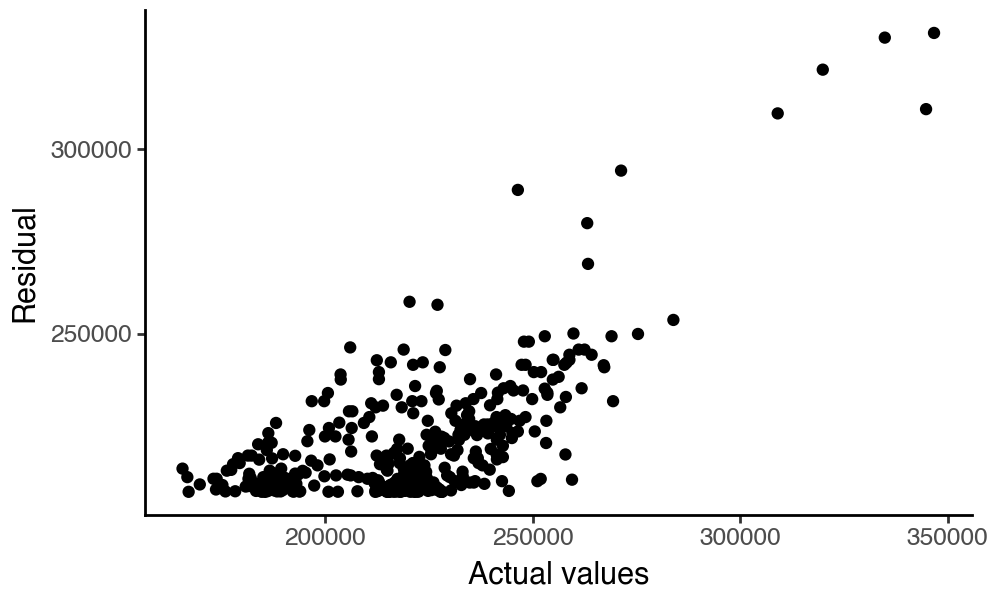

In [226]:
xmin = df_result['total_demand'].min() - 1e4
xmax = df_result['total_demand'].max() +  1e4

ymin = df_result['LinearRegression'].min() - 1e4
ymax = df_result['LinearRegression'].max() +  1e4

(ggplot(data=df_result, mapping=aes(x='total_demand', y='LinearRegression')) + 
    geom_point() + 
    labs(x='Actual values', y='Residual') + 
    # lims(x=(ymin, ymax), y=(ymin, ymax)) +
    theme_classic() + 
    theme(figure_size=(5, 3)))

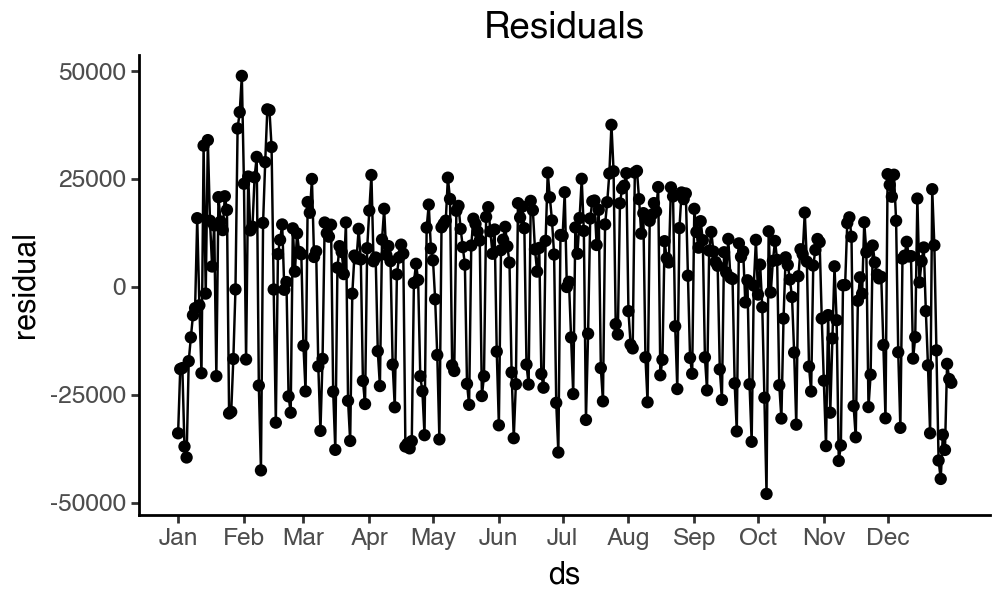

In [211]:
# residuals display unequal variance over time. 
breaks = pd.date_range(start=df_result['ds'].min(), 
                       end=df_result['ds'].max(), 
                       freq='MS')  # Month Start

(ggplot(data=df_result, mapping=aes(x='ds', y='residual')) + 
    geom_point() + 
    geom_line() + 
    ggtitle(title="Residuals") + 
    scale_x_date(breaks=breaks, labels=lambda dates: [d.strftime("%b") for d in dates]) +
    theme_classic() + 
    theme(figure_size=(5, 3)))

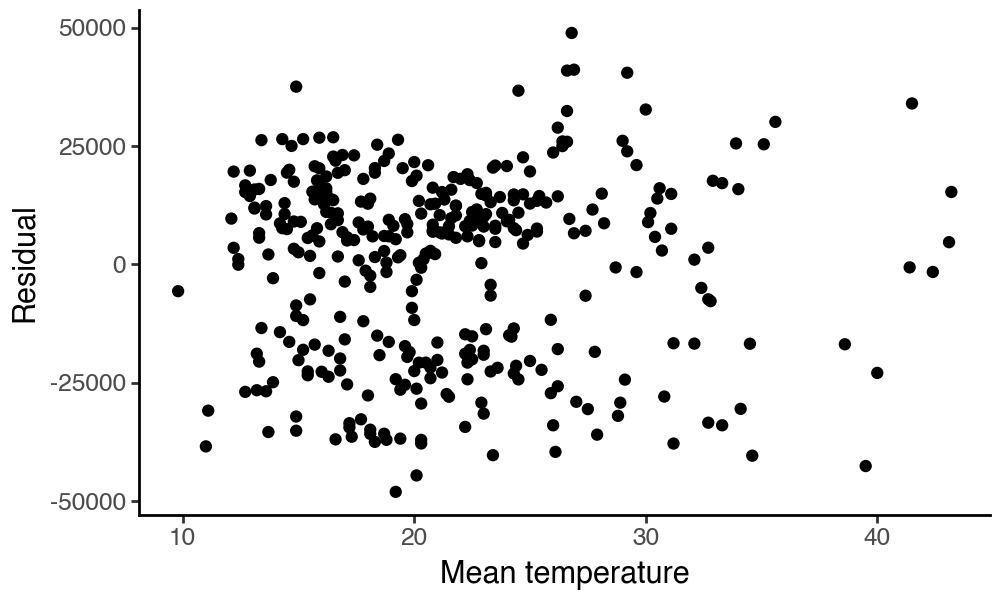

In [ ]:
# Examine residual sizes as function of mean temperature 
# merge in temperature
df_result = df_result.merge(right=df_daily[['ds', 'mean_temp']], how='left', on='ds')

(ggplot(data=df_result, mapping=aes(y='residual', x='mean_temp')) + 
    geom_point() + 
    theme_classic() + 
    labs(x='Mean temperature', y='Residual') + 
    theme(figure_size=(5, 3)))

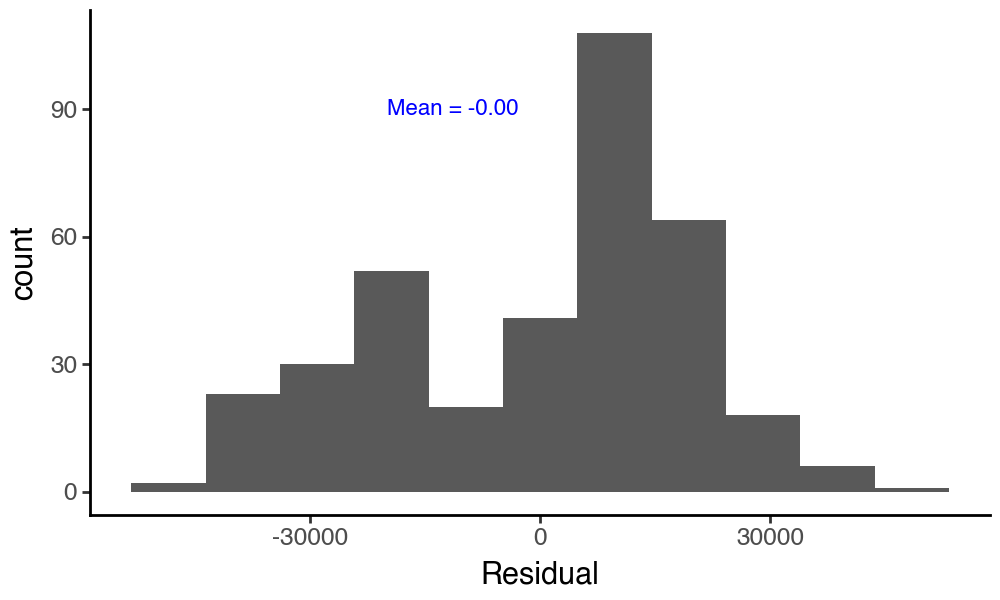

In [233]:
# Histogram of residualts
mean_resid = df_result['residual'].mean()

(ggplot(data=df_result, mapping=aes(x='residual')) + 
    geom_histogram() + 
    theme_classic() + 
    labs(x='Residual') + 
    annotate("text", x=-2e4, y=90, 
               label=f"Mean = {mean_resid:.2f}", ha='left', size=8, color="blue") + 
    theme(figure_size=(5, 3)))

In [286]:
# Scenario 1: Mean temperature =15 
df_future = mf_model.make_future_dataframe(h=1)
df_future['mean_temp'] = 15
df_future['temp_square'] = 15**2

# Create forecasts
df_temp15 = mf_model.predict(h=1, X_df=df_future)
df_temp15['mean_temp'] = 15

# Scenario 1: Mean temperature =35 
df_future = mf_model.make_future_dataframe(h=1)
df_future['mean_temp'] = 35
df_future['temp_square'] = 35**2

# Create forecasts
df_temp35 = mf_model.predict(h=1, X_df=df_future)
df_temp35['mean_temp'] = 35

df_scenario_merged = pd.merge(left=df_temp15, right=df_temp35, 
                              on=['ds', 'unique_id'])

# add in average demand for temperatures of 15 and 35C
avg_15 = df_daily.loc[df_daily['mean_temp'].le(15.5) & df_daily['mean_temp'].ge(14.5), 'total_demand'].mean()
avg_35 = df_daily.loc[df_daily['mean_temp'].le(35.5) & df_daily['mean_temp'].ge(34.5), 'total_demand'].mean()

# when using squared temperature, predictions make sense 
df_combined = pd.concat(objs=[df_temp15, df_temp35], ignore_index=True)
df_combined['mean_demand'] = [avg_15, avg_35]
df_combined['difference'] = df_combined['LinearRegression'] - df_combined['mean_demand']
df_combined

,unique_id,ds,LinearRegression,mean_temp,mean_demand,difference
0,elec_demand,2015-01-01,231248.193904,15,230450.964884,797.229020
1,elec_demand,2015-01-01,249247.991137,35,236757.528747,12490.462391


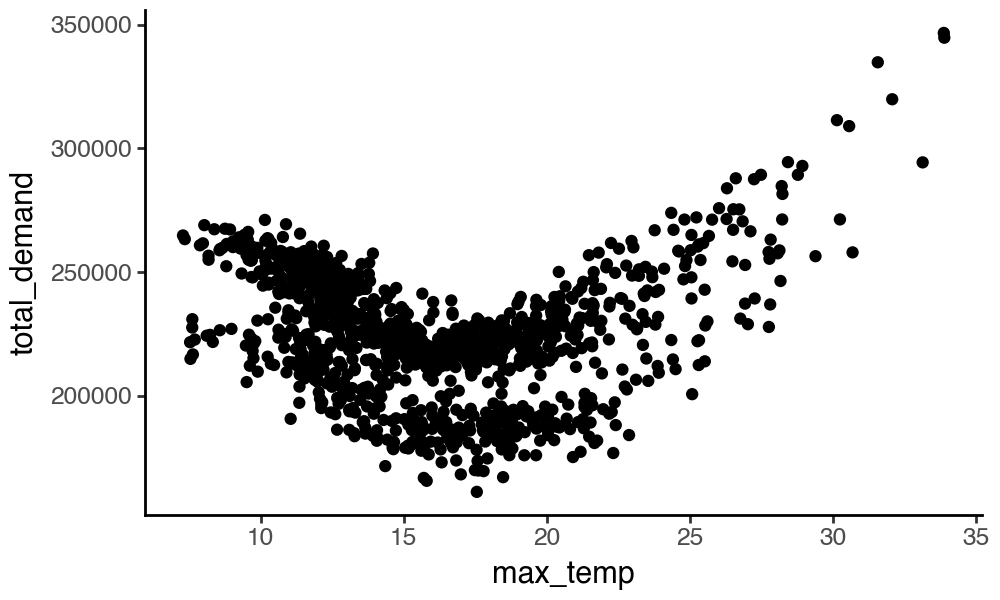

In [ ]:
# Demand vs Mean Temperature for all data
df_elec = pd.read_csv('data/raw/vic_elec.csv', parse_dates=['ds'])

df_wide = df_elec.pivot(index=['ds'], columns=['unique_id'], values='y').reset_index()

# compute daily aggregates 
df_daily = (df_wide.resample('D', on='ds').agg({'Demand': 'sum',       
       'Temperature': 'mean', 
       "Temperature": ["max", 'mean']}))

df_daily.columns = ['total_demand', 'mean_temp', 'max_temp']
df_daily = df_daily.reset_index()

# add temperature^2
df_daily['temp_square'] = df_daily['mean_temp']**2
df_long = df_daily.melt(id_vars=['ds'])

(ggplot(data=df_daily, mapping=aes(x='mean_temp', y='total_demand')) + 
 geom_point() + 
 theme_classic() + 
 theme(figure_size=(5, 3)))

### 7.3. Elasticity coefficient


Consider the log-log model of

$$
\log{y} = \beta_0 + \beta_1 \log{x} + \epsilon.
$$

Exponentiation of both sides results in 

$$
y = e^{\beta_0}e^{\beta_1}e^{\epsilon}.
$$

Then differentiating y with respect to x 

$$
\frac{dy}{dx} =\beta_1 e^{\beta_0}e^{\epsilon}x^{\beta_1} = \beta_1 \frac{y}{x}
$$

### 7.4. Monthly sale figures for souvenir shop 

### 7.5. US gasoline motor products fitted with Fourier series

Recap: Any periodic function can be approximated by the right frequency of sine and cosine terms. Model with two harmonics captures general trend, but not any spikes.

Using only two harmonics, the predictions capture the general trend but are not sensitve to spikes. Using the AICc and cross-validation scores, the best model seems to be with 6 harmonics. Using this model, predictions are more sensitive to spikes. 

In [109]:
df_gas = pd.read_csv('data/raw/us_gasoline.csv', parse_dates=['ds'])

# isolate only for data until 2004 
df_2004 = df_gas.loc[df_gas['ds'].le('2005')]

# create fourier data set 
df_fourier = df_2004.copy()

# Acreates a time index feature that increases by 1 each period to allow regression model to capture
# long-term change 
df_fourier, _ = trend(df_fourier, freq="W")

# Add fourier features. Include 2 harmonics 
df_fourier, _ = fourier(df_fourier, freq="W", k=2, season_length=52)

mf = MLForecast(models=LinearRegression(),freq="W",)

msg_fit = mf.fit(df_fourier, fitted=True, static_features=[])

insample_forecasts = mf.forecast_fitted_values()["LinearRegression"]
residuals = mf.models_["LinearRegression"]._residuals

df_sample_pred = mf.forecast_fitted_values()
df_sample_pred['residual'] = df_sample_pred['y'] - df_sample_pred['LinearRegression']


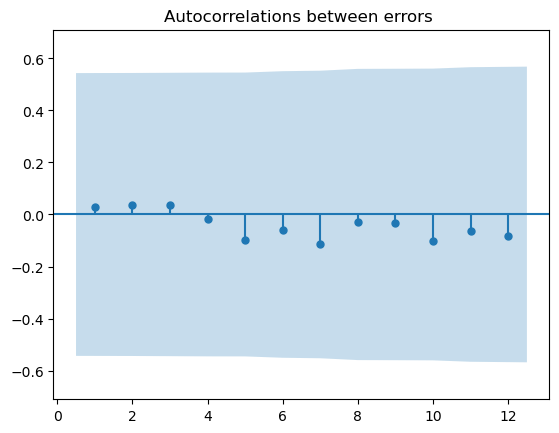

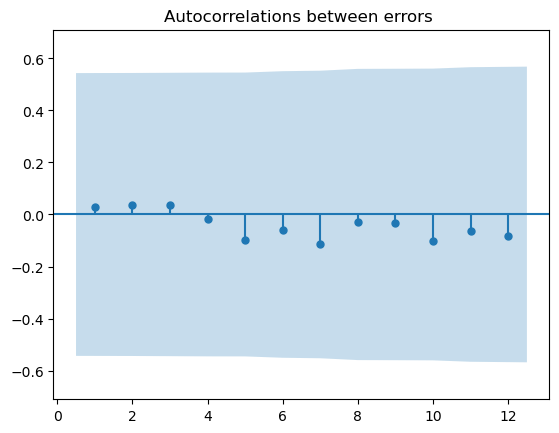

In [110]:
# plot of resisduals against observed values
(ggplot(data=df_sample_pred, mapping=aes(x='y', y='residual')) + 
    geom_point() +
    ggtitle('Residuals as function of observed value') + 
    theme_classic())

# plot of resituals over time
(ggplot(data=df_sample_pred, mapping=aes(x='ds', y='residual')) + 
    geom_point() +
    ggtitle('Residuals over time') + 
    theme_classic())

# autocorrelation between errors
from statsmodels.tsa.stattools import acf

# Compute autocorrelations for lags 1 to 22
resid_acf = acf(df_sample_pred['residual'], nlags=12, fft=False)
plot_acf(x=resid_acf, lags=12,
         zero=False, bartlett_confint=True, auto_ylims=True, 
         title="Autocorrelations between errors ")


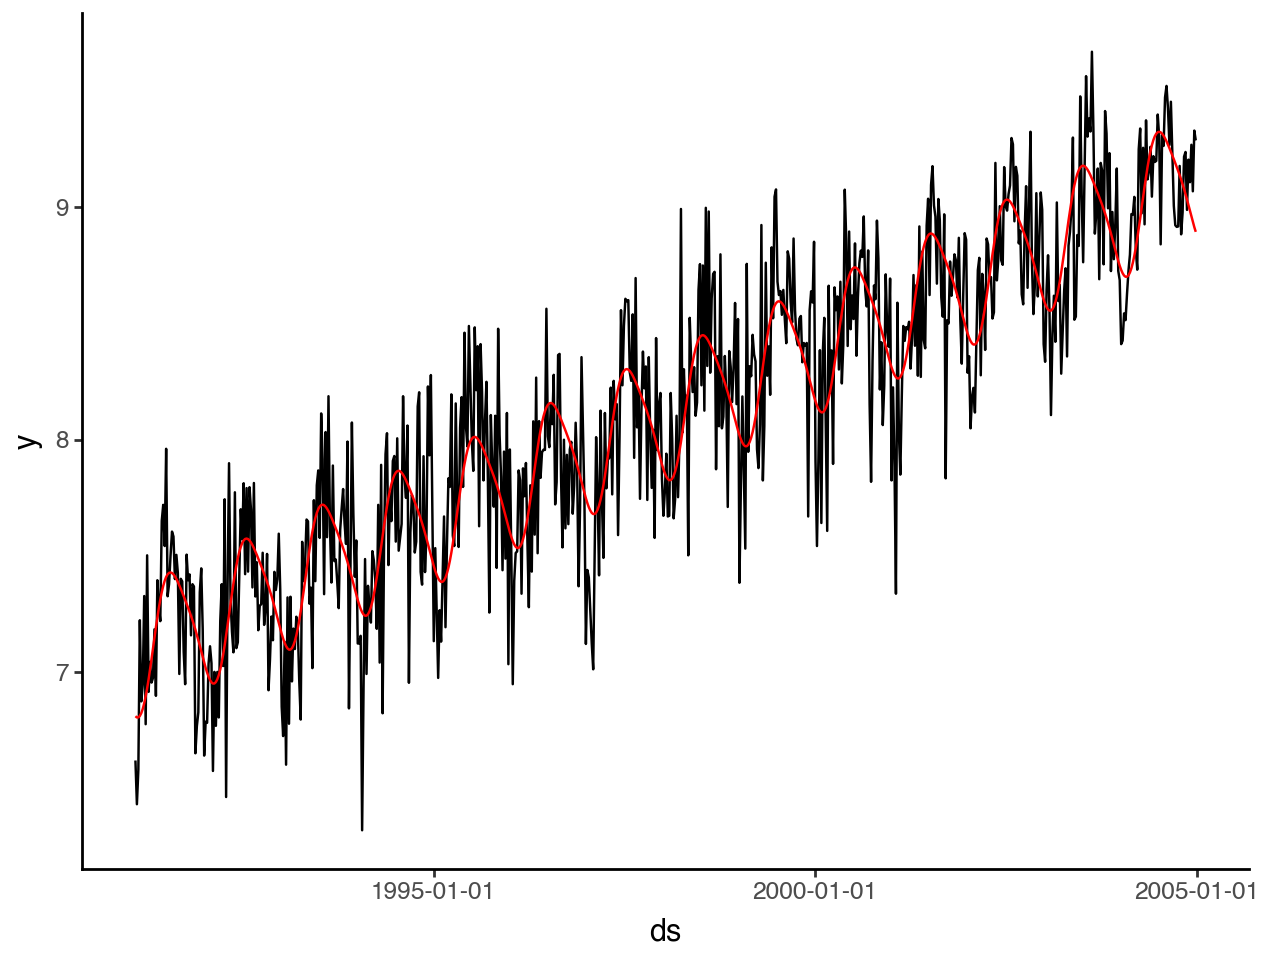

In [ ]:
# observed vs predicted values over time 
df_long = df_sample_pred.melt(id_vars=['unique_id', 'ds', 'residual'],   # keep these as identifiers
    value_vars=['y', 'LinearRegression'])

(ggplot(data=df_sample_pred, mapping=aes(x='ds', y='y')) + 
    geom_line() + 
    geom_line(inherit_aes=False, data=df_sample_pred, 
              mapping=aes(x='ds', y='LinearRegression'), color='red') + 
    theme_classic())

In [ ]:
# Acreates a time index feature that increases by 1 each period to allow regression model to capture
df_gas = pd.read_csv('data/raw/us_gasoline.csv', parse_dates=['ds'])
# filter until 2005
df_2004 = df_gas.loc[df_gas['ds'].le('2005')].copy()

series_freq = "W-MON"
df_fourier, _ = trend(df_2004, freq=series_freq)
mf = MLForecast(models=LinearRegression(),freq=series_freq,)


# Add fourier features. Include 2 harmonics 
num_harmonics = list(np.arange(start=1, stop=11))
df_model_eval = pd.DataFrame({"num_harmonics": num_harmonics, 
                              "AICc": np.nan, 
                              "cv_score": np.nan})

for idx, row in df_model_eval.iterrows(): 

    num = int(row['num_harmonics'])
    df_fourier, _ = fourier(df_fourier, freq=series_freq, k=num, season_length=52)

    # fit model 
    message = mf.fit(df=df_fourier, fitted=True, static_features=[]); 
    
    # extract insample forecsats 
    insample_forecasts = mf.forecast_fitted_values()["LinearRegression"]
    obs_values = mf.forecast_fitted_values()["y"]

    # compute AICc
    T = len(obs_values)
    k = len(mf.models_["LinearRegression"].coef_)

    # compute AICc and cross-validation scores
    df_model_eval.loc[idx, 'AICc'] = aicc_score(y=obs_values, y_hat=insample_forecasts, T=T, k=k)
    df_model_eval.loc[idx, 'cv_score'] = cv_score(mf=mf, df=df_fourier, model='LinearRegression', target_col='y', n_windows=5, h=1)

# 6 harmonics seems to provide the best model 

,num_harmonics,AICc,cv_score
0,1,-1808.997299,0.557431
1,2,-1814.477013,0.479454
2,3,-1852.646012,0.513005
3,4,-1856.303530,0.517125
4,5,-1862.414131,0.446195
5,6,-1883.541628,0.389377
6,7,-1887.354229,0.440107
7,8,-1884.572743,0.457083
8,9,-1881.946563,0.488032
9,10,-1881.415444,0.489783


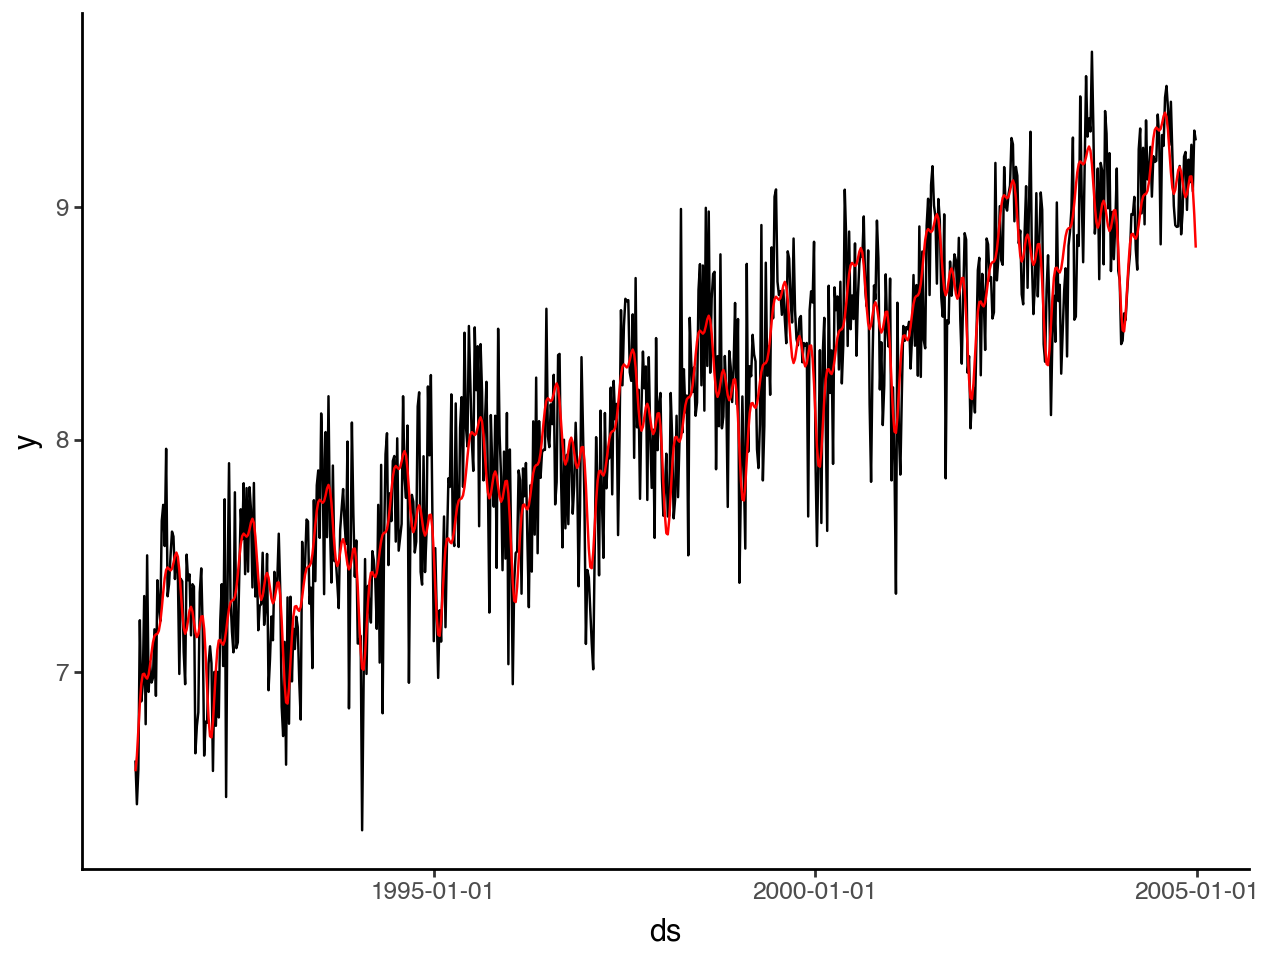

In [114]:
df_gas = pd.read_csv('data/raw/us_gasoline.csv', parse_dates=['ds'])

# isolate only for data until 2004 
df_2004 = df_gas.loc[df_gas['ds'].le('2005')]

# create fourier data set 
df_fourier = df_2004.copy()

# Acreates a time index feature that increases by 1 each period to allow regression model to capture
# long-term change 
freq = "W-MON"
df_fourier, _ = trend(df_fourier, freq=freq)

# Add fourier features. Include 2 harmonics 
df_fourier, _ = fourier(df_fourier, freq=freq, k=6, season_length=52)

mf = MLForecast(models=LinearRegression(),freq=freq,)

msg_fit = mf.fit(df_fourier, fitted=True, static_features=[])

insample_forecasts = mf.forecast_fitted_values()["LinearRegression"]
residuals = mf.models_["LinearRegression"]._residuals

df_sample_pred = mf.forecast_fitted_values()
df_sample_pred['residual'] = df_sample_pred['y'] - df_sample_pred['LinearRegression']

# observed vs predicted values over time 
df_long = df_sample_pred.melt(id_vars=['unique_id', 'ds', 'residual'],   # keep these as identifiers
    value_vars=['y', 'LinearRegression'])

(ggplot(data=df_sample_pred, mapping=aes(x='ds', y='y')) + 
    geom_line() + 
    geom_line(inherit_aes=False, data=df_sample_pred, 
              mapping=aes(x='ds', y='LinearRegression'), color='red') + 
    theme_classic())

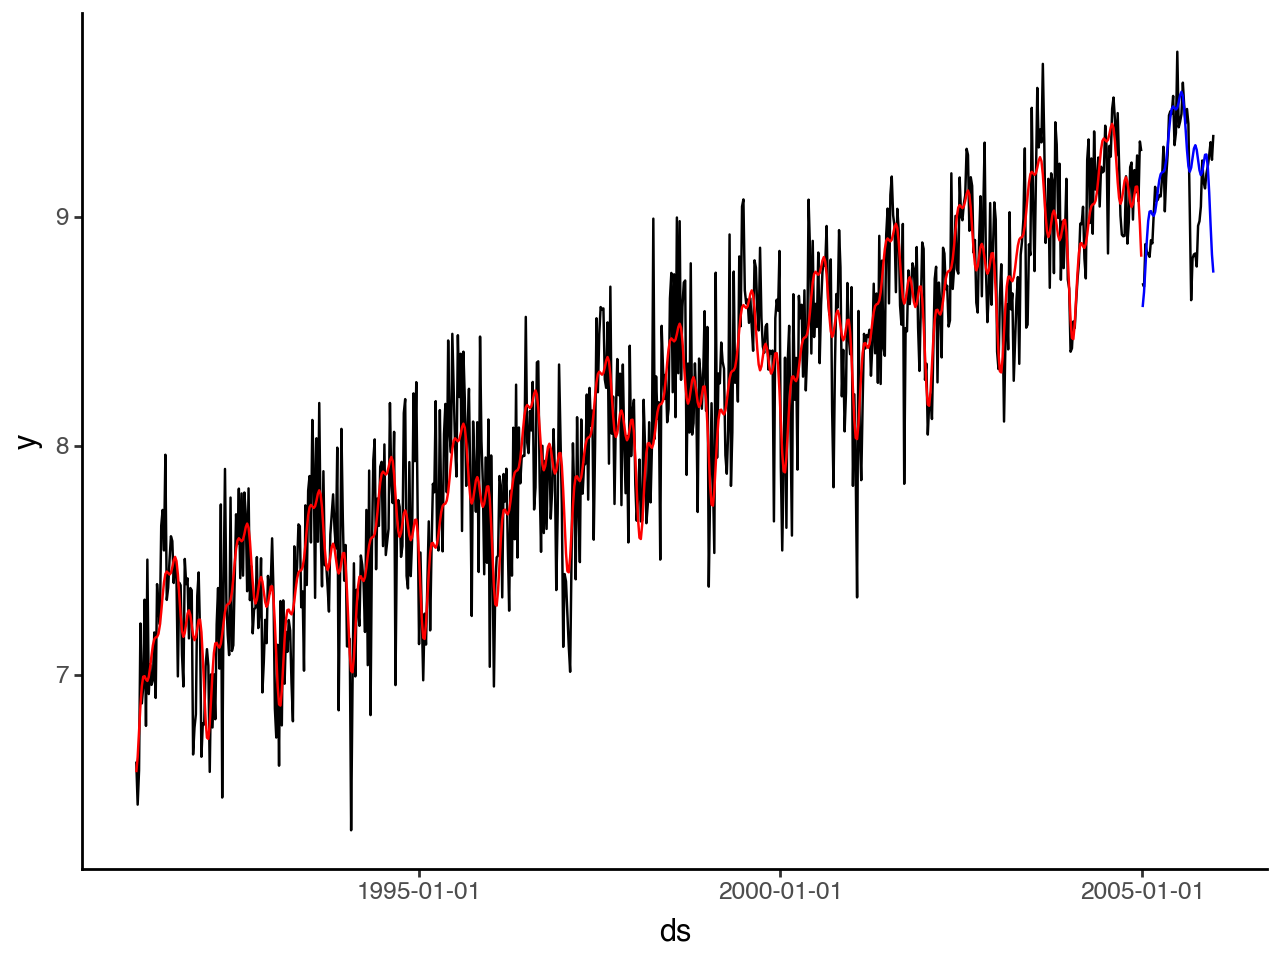

In [ ]:
# Evaluation of forecasts on completely unseen data 
df_gas = pd.read_csv('data/raw/us_gasoline.csv', parse_dates=['ds'])

# isolate only for data until 2004 
df_2005 = df_gas.loc[df_gas['ds'].gt('2005') & 
                     df_gas['ds'].lt('2006')]

df_2005, _ = trend(df_2005, freq="W-MON")
df_2005['trend'] = df_fourier['trend'].max() + df_2005['trend']

df_2005, _ = fourier(df_2005, freq="W-MON", k=6, season_length=52)
df_pred_2005 = mf.predict(h=52, X_df=df_2005 )

# merge with 2005 data 
df_pred_2005 = df_pred_2005.merge(right=df_2005[['ds', 'y']], on=['ds'])

# concatenate with prediction data
(ggplot(data=df_sample_pred, mapping=aes(x='ds', y='y')) + 
    geom_line() + 
    geom_line(inherit_aes=False, data=df_sample_pred, 
              mapping=aes(x='ds', y='LinearRegression'), color='red') + 
    geom_line(inherit_aes=False, data=df_pred_2005, mapping=aes(x='ds', y='y')) + 
    geom_line(inherit_aes=False, data=df_pred_2005, 
              mapping=aes(x='ds', y='LinearRegression'), color='blue') +
    theme_classic())

In [ ]:
# NOTE: little test to see that the trend value is very important
df_pred_2005, _ = trend(df_pred_2005, freq="W-MON")
df_pred_2005['trend'] = df_fourier['trend'].max() + df_pred_2005['trend']

# predict only the 750 trend instance
df_test = df_2005.copy()

df_test.loc[df_test['trend'].eq(740), 'trend'] = 727
mf.predict(h=1, X_df=df_test )


,unique_id,ds,LinearRegression
0,us_gasoline,2005-01-03,8.605738


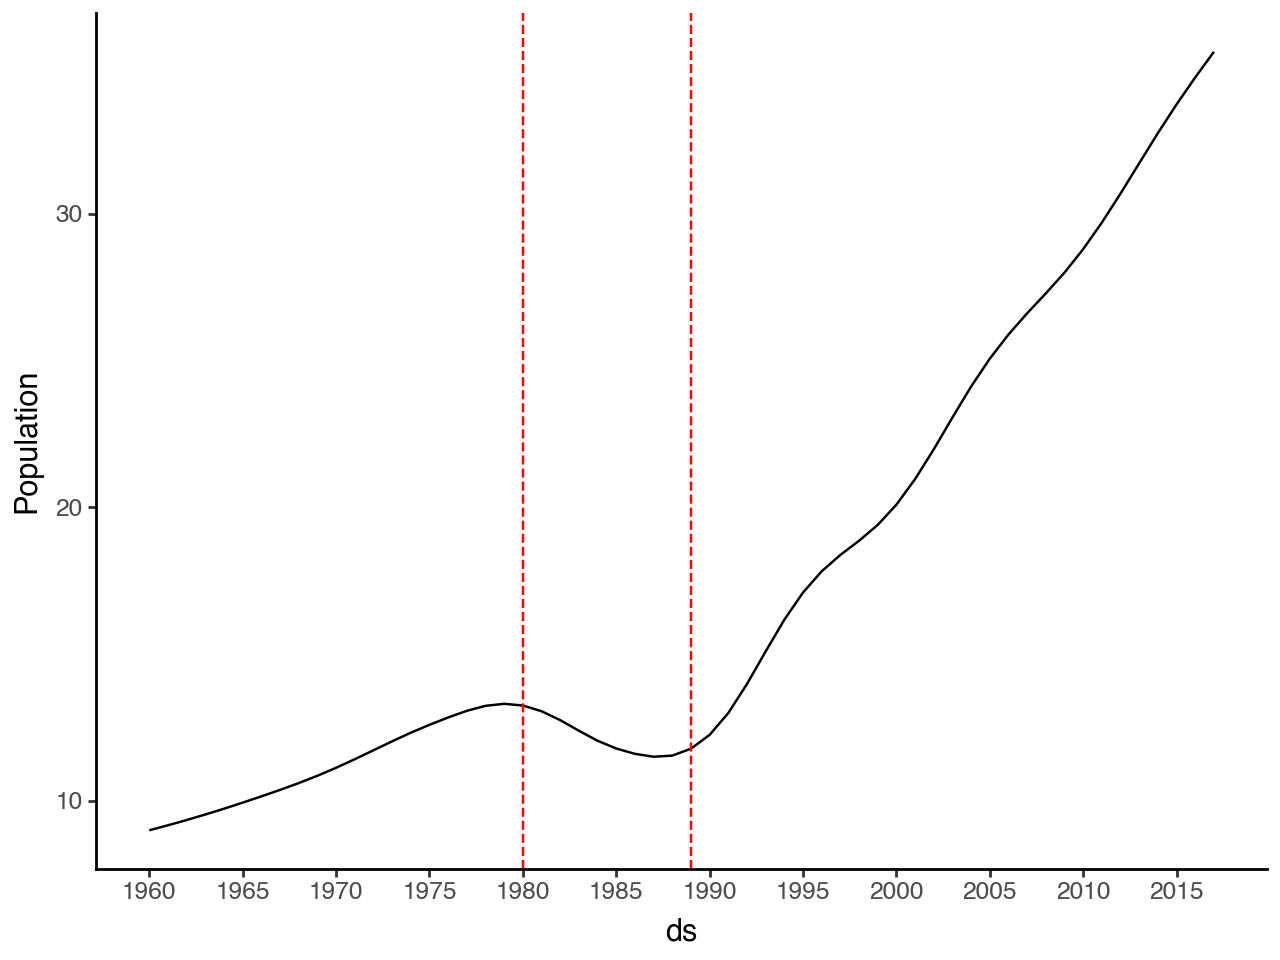

In [162]:
df_pop = pd.read_csv('data/raw/global_economy.csv', parse_dates=['ds'])

df_afghan = df_pop.loc[df_pop['Code'].eq('AFG')]

(ggplot(data=df_afghan, mapping=aes(x='ds', y=df_afghan['Population']/1e6)) + 
    geom_line() + 
    scale_x_datetime(date_breaks="5 years",  # tick every 5 years
                  date_labels="%Y") + 
    geom_vline(xintercept=pd.to_datetime("1980-01-01"), linetype="dashed", color="red") +
    geom_vline(xintercept=pd.to_datetime("1989-01-01"), linetype="dashed", color="red") +
    theme_classic())